# Chapter 3 — goodness-of-fit main-text figures

Single metric: **Mahalanobis $\chi^2/N$**, shown in two covariance budgets —
**full covariance** ($\sigma_{\mathrm{exp}}\oplus\sigma_{\mathrm{eval}}$, internal `V4`)
and **EXFOR only** ($\sigma_{\mathrm{exp}}$, MF34 removed, internal `V2`).

Reads precomputed **`run_080`** results — the rebuilt run80 pipeline output
(`merge_mf34` call-site fix + `MF34_to_MG` cache fix). Three $c_0$-reference
methodologies are loaded; the **EXFOR-$c_0$** set is the main-text one, the
**resolution-folded** set is new this run. **No figures are written to disk** —
each cell renders inline; save manually from the notebook.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# Run + methodology configuration
# ---------------------------------------------------------------------------
# run_080 = first chi2 analysis on the run80 pipeline ENDF (26-Fe-56g_nominal_mg.endf,
# rebuilt with the merge_mf34 + MF34_to_MG cache fixes). Numbers move only slightly
# vs run_079; the "manuscript delta" cell at the end prints the exact prose updates.
RUN = '080'
CHI_BASE = Path('/share_snc/snc/JuanMonleon/CHI_Figures')

# c0-reference methodologies, all computed for this run:
#   exfor_c0          - c0 from the EXFOR Kinney/Smith fit; EXFOR systematics blocked
#                       per incident energy. Manuscript main-text methodology.
#   folded_c0         - c0 from the resolution-folded library MF3; EXFOR systematics
#                       global (experiment-wide). Scores each evaluation as the
#                       detector would have measured it (finite TOF resolution).
#   library_c0        - c0 from the raw library MF3 (loaded for completeness).
#   folded_al_c0_ns{1,3} - like folded_c0 but the angular shape a_l is ALSO folded
#                       over the TOF resolution window (truncated Gaussian), at
#                       window half-widths of +/-1 sigma and +/-3 sigma. Lets us see
#                       how much folding the shape (and the window width) matters.
METHODS = {
    'exfor_c0':          'chi2_exfor_c0',
    'folded_c0':         'chi2_folded_c0',
    'library_c0':        'chi2_library_c0',
    'folded_al_c0_ns1':  'chi2_folded_al_c0_ns1',
    'folded_al_c0_ns3':  'chi2_folded_al_c0_ns3',
}
METHOD_TITLE = {
    'exfor_c0':          r'EXFOR $c_0$ (main text)',
    'folded_c0':         r'Resolution-folded $c_0$ (new)',
    'library_c0':        r'Library $c_0$',
    'folded_al_c0_ns1':  r'Folded $c_0$ \& $a_l$ ($\pm1\sigma$)',
    'folded_al_c0_ns3':  r'Folded $c_0$ \& $a_l$ ($\pm3\sigma$)',
}
def run_dir(method):
    return CHI_BASE / METHODS[method] / f'run_{RUN}'

plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'legend.frameon': False,
})

# Thesis library palette: JEFF/JENDL from the kika colorblind set, this work in red.
COLOR = {
    'JEFF-4.0':  '#0173B2',
    'JENDL-5':   '#029E73',
    'This work': '#D62728',
}
LIBS = ['JEFF-4.0', 'JENDL-5', 'This work']
LIB_RAW_TO_DISPLAY = {'JEFF': 'JEFF-4.0', 'JENDL': 'JENDL-5', 'This_work': 'This work'}

SUBSETS = [
    ('all',                'All experiments'),
    ('no_Cierjacks',       'Excluding Cierjacks 1978'),
    ('no_KS',              'Excluding Kinney & Smith'),
    ('no_KS_no_Cierjacks', 'Excluding K&S and Cierjacks'),
    ('only_KS',            'Kinney & Smith only'),
    ('only_Cierjacks',     'Cierjacks only'),
]

# The single metric, in its two covariance budgets. PRIMARY (full covariance) is
# reported throughout the section; COMPANION (EXFOR only) is its MF34-removed
# counterpart.
PRIMARY   = 'V4'
COMPANION = 'V2'
BUDGET_NAME = {'V1': 'diagonal', 'V2': 'EXFOR only',
               'V3': 'rank-2 + diag eval', 'V4': 'full covariance'}
VARIANT_TITLE = {
    'V4': r'Full covariance ($\sigma_{\mathrm{exp}}\oplus\sigma_{\mathrm{eval}}$)',
    'V2': r'EXFOR only, MF34 removed ($\sigma_{\mathrm{exp}}$)',
    'V1': r'Diagonal only ($\sigma_{\mathrm{exp}}$, uncorrelated)',
}

In [2]:
def load_summary(method):
    with (run_dir(method) / 'summary.json').open() as fh:
        return json.load(fh)

# Load whatever results exist. Methods whose run_080 report is not on disk yet
# (e.g. folded_al_c0_ns{1,3} before the cluster job has run) are skipped with a
# note, so this notebook still runs on the methods already computed.
SUMM = {}
for m in METHODS:
    try:
        SUMM[m] = load_summary(m)
    except FileNotFoundError:
        print(f'[skip] no results yet for {m!r}  ({run_dir(m)})')

def col(lib_raw, variant):
    return f'{lib_raw}_{variant}'

def subset_total(method, sub_key, lib_disp, variant):
    for r in SUMM[method]['per_subset_all_variants'][sub_key]:
        if r['Library'] == lib_disp:
            return r[f'chi2_{variant.lower()}_per_N']
    raise KeyError(f'{method} / {sub_key} / {lib_disp}')

def subset_N(method, sub_key):
    return SUMM[method]['per_subset_all_variants'][sub_key][0]['N']

def win_tally_for(method, variant):
    return {
        r['Library']: {'best':  r[f'{variant} best'],
                       'mid':   r[f'{variant} mid'],
                       'worst': r[f'{variant} worst']}
        for r in SUMM[method]['win_tally_per_subset']['all']
    }

for m in ('exfor_c0', 'folded_c0', 'folded_al_c0_ns1', 'folded_al_c0_ns3'):
    if m not in SUMM:
        continue
    print(f'=== {METHOD_TITLE[m]} - run_{RUN} '
          f'(experiments: {SUMM[m]["n_experiments"]}) ===')
    for v in (PRIMARY, COMPANION):
        print(f'  [{BUDGET_NAME[v]}]  all-experiments chi2/N:')
        for lib in LIBS:
            print(f'    {lib:<10s} {subset_total(m, "all", lib, v):8.2f}')

=== EXFOR $c_0$ (main text) - run_080 (experiments: 67) ===
  [full covariance]  all-experiments chi2/N:
    JEFF-4.0      20.01
    JENDL-5       24.50
    This work      8.02
  [EXFOR only]  all-experiments chi2/N:
    JEFF-4.0      32.87
    JENDL-5       33.10
    This work     15.89
=== Resolution-folded $c_0$ (new) - run_080 (experiments: 67) ===
  [full covariance]  all-experiments chi2/N:
    JEFF-4.0      35.55
    JENDL-5       45.71
    This work     25.10
  [EXFOR only]  all-experiments chi2/N:
    JEFF-4.0      57.41
    JENDL-5       60.19
    This work     42.61
=== Folded $c_0$ \& $a_l$ ($\pm1\sigma$) - run_080 (experiments: 67) ===
  [full covariance]  all-experiments chi2/N:
    JEFF-4.0      19.88
    JENDL-5       31.22
    This work     13.87
  [EXFOR only]  all-experiments chi2/N:
    JEFF-4.0      42.39
    JENDL-5       47.34
    This work     38.83
=== Folded $c_0$ \& $a_l$ ($\pm3\sigma$) - run_080 (experiments: 67) ===
  [full covariance]  all-experiments chi2

In [3]:
def load_per_exp(method):
    d = run_dir(method) / 'per_experiment'
    return {sub: pd.read_csv(d / f'per_experiment_{sub}.csv') for sub, _ in SUBSETS}

# Same skip-if-missing policy as SUMM above.
PER_EXP = {}
for m in METHODS:
    try:
        PER_EXP[m] = load_per_exp(m)
    except FileNotFoundError:
        print(f'[skip] no per-experiment CSVs yet for {m!r}')

print({m: {k: len(v) for k, v in PER_EXP[m].items()} for m in PER_EXP})
PER_EXP['exfor_c0']['all'].head()

{'exfor_c0': {'all': 67, 'no_Cierjacks': 66, 'no_KS': 65, 'no_KS_no_Cierjacks': 64, 'only_KS': 2, 'only_Cierjacks': 1}, 'folded_c0': {'all': 67, 'no_Cierjacks': 66, 'no_KS': 65, 'no_KS_no_Cierjacks': 64, 'only_KS': 2, 'only_Cierjacks': 1}, 'library_c0': {'all': 67, 'no_Cierjacks': 66, 'no_KS': 65, 'no_KS_no_Cierjacks': 64, 'only_KS': 2, 'only_Cierjacks': 1}, 'folded_al_c0_ns1': {'all': 67, 'no_Cierjacks': 66, 'no_KS': 65, 'no_KS_no_Cierjacks': 64, 'only_KS': 2, 'only_Cierjacks': 1}, 'folded_al_c0_ns3': {'all': 67, 'no_Cierjacks': 66, 'no_KS': 65, 'no_KS_no_Cierjacks': 64, 'only_KS': 2, 'only_Cierjacks': 1}}


,experiment_id,author,year,E_min,E_max,JEFF_V1,JENDL_V1,This_work_V1,JEFF_V2,JENDL_V2,This_work_V2,JEFF_V3,JENDL_V3,This_work_V3,JEFF_V4,JENDL_V4,This_work_V4,N
0,20482005,Cabe,1967,0.9700,0.9700,73.633435,18.189067,2.522313,3267.293857,6022.503443,300.573467,80.924760,17.341295,2.790235,112.845338,1808.442347,16.107298,11
1,20008013,Tomita,1973,1.9400,1.9400,27.924367,9.220614,2.834661,1572.141295,3256.089563,88.097751,33.765901,9.751503,6.143904,20.620383,822.253894,8.427401,14
2,20008004,Tomita,1973,1.5560,1.5560,7.182724,12.114850,1.947369,924.050808,2159.255411,39.057468,9.529266,17.640114,1.880049,42.792201,715.417378,9.380596,13
3,20008003,Tomita,1973,1.4700,1.4700,241.466337,9.153267,7.550318,71.133002,2090.595678,208.738282,39.764864,12.694101,22.265232,31.476455,551.877319,13.857580,13
4,10332004,Cox,1972,0.9021,0.9021,10.886849,5.513287,2.422660,861.968009,1749.719994,142.007634,15.978638,5.195062,5.080341,74.245866,241.618513,32.580784,8


In [4]:
# ---- Plotting helpers (parametrised by methodology) ------------------------
def plot_subset_panel(method, variants=(PRIMARY, COMPANION)):
    subset_keys   = [s[0] for s in SUBSETS]
    subset_labels = [s[1] for s in SUBSETS]
    for variant in variants:
        fig, ax = plt.subplots(figsize=(7.2, 4.4))
        y_pos = np.arange(len(SUBSETS))
        bar_h = 0.26
        max_val = 0.0
        for i, lib in enumerate(LIBS):
            vals = [subset_total(method, sub, lib, variant) for sub in subset_keys]
            max_val = max(max_val, max(vals))
            bars = ax.barh(y_pos + (i - 1) * bar_h, vals, height=bar_h,
                           color=COLOR[lib], label=lib)
            for bar, val in zip(bars, vals):
                ax.text(val + max_val * 0.01, bar.get_y() + bar.get_height() / 2,
                        f'{val:.2f}', va='center', fontsize=8, color='#333')
        ns = [subset_N(method, sub) for sub in subset_keys]
        ax.set_yticks(y_pos)
        ax.set_yticklabels([f'{lab}\n($N={n:,}$)' for lab, n in zip(subset_labels, ns)])
        ax.invert_yaxis()
        ax.set_xlabel(r'$\chi^2/N$')
        ax.set_xlim(0, max_val * 1.15)
        ax.set_title(f'{METHOD_TITLE[method]}\n{VARIANT_TITLE[variant]}')
        ax.legend(loc='lower right')
        fig.tight_layout()
        plt.show()


def plot_strip(method, variant=PRIMARY):
    df = PER_EXP[method]['all'].sort_values(col('This_work', variant)).reset_index(drop=True)
    rank = np.arange(len(df))
    fig, ax = plt.subplots(figsize=(7.2, 4.8))
    for lib_raw, lib_disp in LIB_RAW_TO_DISPLAY.items():
        ax.scatter(rank, df[col(lib_raw, variant)],
                   color=COLOR[lib_disp], s=14, alpha=0.85, label=lib_disp)
    ax.set_yscale('log')
    ax.axhline(1, color='#555', lw=0.8, linestyle=':')
    ax.set_xlabel(r'Experiments, ranked by $\chi^2/N$ of this work (ascending)')
    ax.set_ylabel(r'$\chi^2/N$ per experiment')
    ax.set_title(f'{METHOD_TITLE[method]} - per-experiment $\\chi^2/N$, '
                 f'{BUDGET_NAME[variant]} (all {len(df)} experiments)')
    ax.legend(loc='upper left')
    fig.tight_layout()
    plt.show()


def plot_wintally(method, variant=PRIMARY):
    wins = win_tally_for(method, variant)
    n_exp = sum(wins['JEFF-4.0'].values())
    fig, ax = plt.subplots(figsize=(6.2, 3.6))
    bar_w = 0.25
    for i, lib in enumerate(LIBS):
        xs = np.array([0, 1, 2]) + (i - 1) * bar_w
        ys = [wins[lib]['best'], wins[lib]['mid'], wins[lib]['worst']]
        bars = ax.bar(xs, ys, width=bar_w, color=COLOR[lib], label=lib)
        for bar, y in zip(bars, ys):
            ax.text(bar.get_x() + bar.get_width() / 2, y + 0.5, str(int(y)),
                    ha='center', fontsize=9)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['best', 'mid', 'worst'])
    ax.set_ylabel('Experiments')
    ax.set_title(f'{METHOD_TITLE[method]} - per-experiment rank, '
                 f'{BUDGET_NAME[variant]} (all {n_exp} experiments)')
    ax.legend(loc='upper right')
    fig.tight_layout()
    plt.show()


def plot_gkatis(method, variant=PRIMARY):
    GKATIS_ID = '27673002'
    dfa = PER_EXP[method]['all']
    gkatis = dfa[dfa['experiment_id'].astype(str) == GKATIS_ID].iloc[0]
    fig, ax = plt.subplots(figsize=(5.6, 3.4))
    vals = [gkatis[col(lib_raw, variant)] for lib_raw in LIB_RAW_TO_DISPLAY]
    colors = [COLOR[LIB_RAW_TO_DISPLAY[lib_raw]] for lib_raw in LIB_RAW_TO_DISPLAY]
    bars = ax.bar(LIBS, vals, color=colors)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, val,
                f'{val:.1f}', ha='center', va='bottom', fontsize=10)
    ax.set_ylabel(r'$\chi^2/N$')
    ax.set_ylim(0, max(vals) * 1.18)
    ax.set_title(f'{METHOD_TITLE[method]} - Gkatis 2025 '
                 f'({int(gkatis["N"])} points), {BUDGET_NAME[variant]}')
    fig.tight_layout()
    plt.show()

## EXFOR $c_0$ — main-text figures (run_080)

The four manuscript figures (`fig:chi2_v4_summary` / `fig:chi2_v2_summary`,
`fig:chi2_v4_perexp_strip`, `fig:chi2_v4_wintally`, `fig:chi2_gkatis_v4`),
now on run_080.

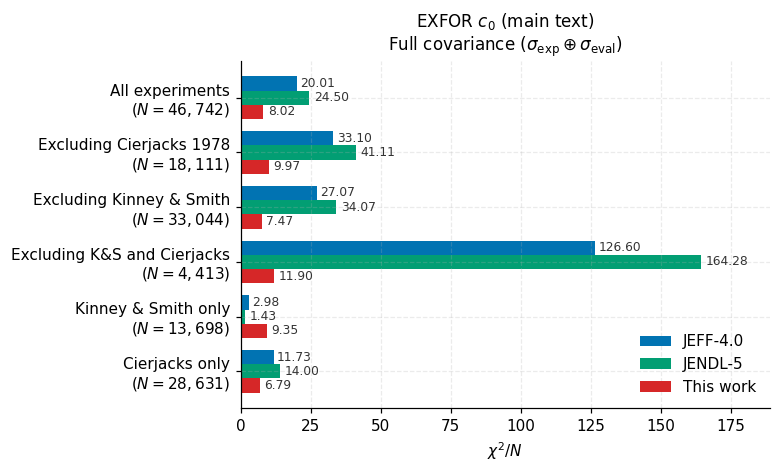

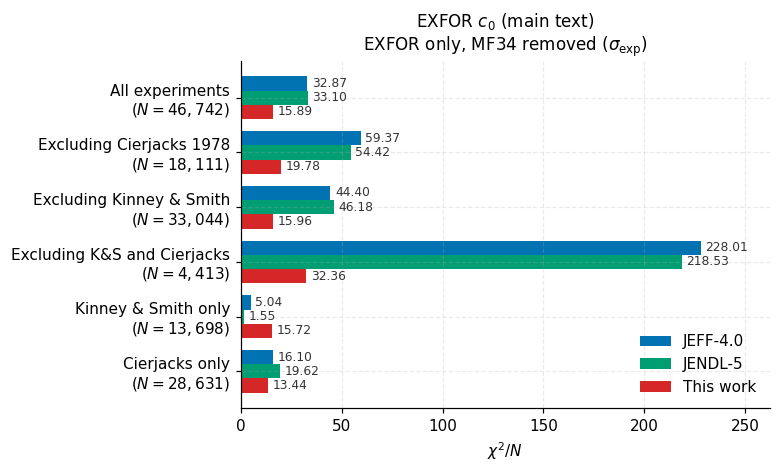

In [5]:
# Subset panel - both covariance budgets (fig:chi2_v4_summary + fig:chi2_v2_summary).
plot_subset_panel('exfor_c0')

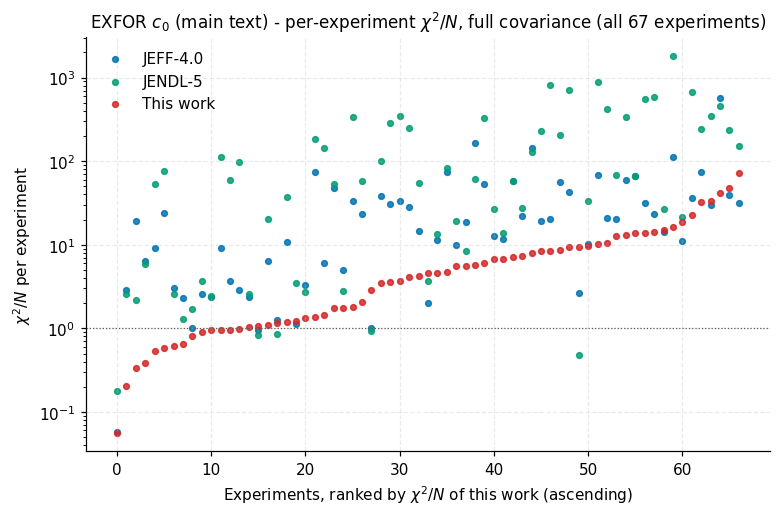

In [6]:
# Per-experiment strip, all 67 experiments (fig:chi2_v4_perexp_strip).
plot_strip('exfor_c0')

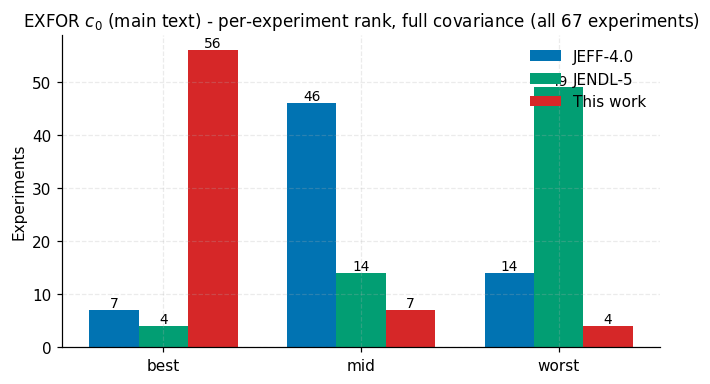

In [7]:
# Per-experiment win-tally, all 67 experiments (fig:chi2_v4_wintally).
plot_wintally('exfor_c0')

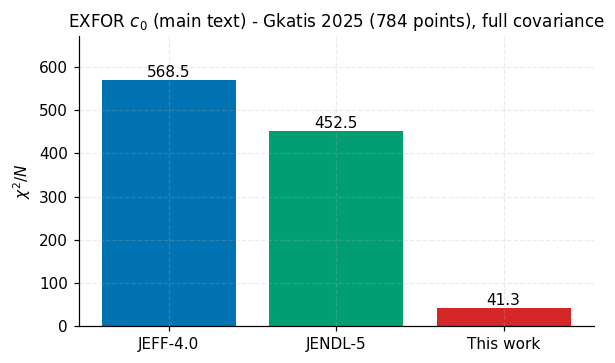

In [8]:
# Gkatis 2025 out-of-sample case study (fig:chi2_gkatis_v4).
plot_gkatis('exfor_c0')

## Resolution-folded $c_0$ — new methodology (run_080)

Reference level $c_0$ from the library MF3 **folded through each experiment's TOF
energy resolution**, so every evaluation is scored as the detector would have seen
it; EXFOR systematics are treated experiment-wide (global).

Folding pulls the three libraries much closer under the diagonal budget (it
absorbs part of the apparent shape mismatch). Under the full-covariance metric
*This work* still gives the lowest $\chi^2/N$ on the full pool and on the hard
no-Cierjacks / no-K&S subsets; on the K&S-only subset the libraries are
comparable. See the cross-methodology table below for the numbers.

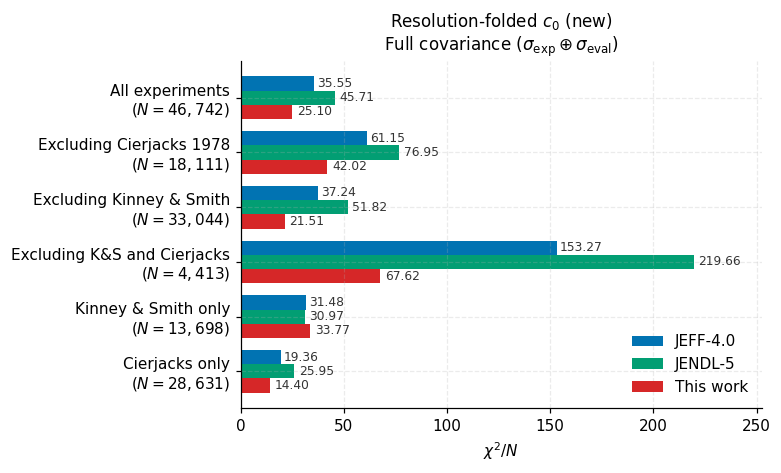

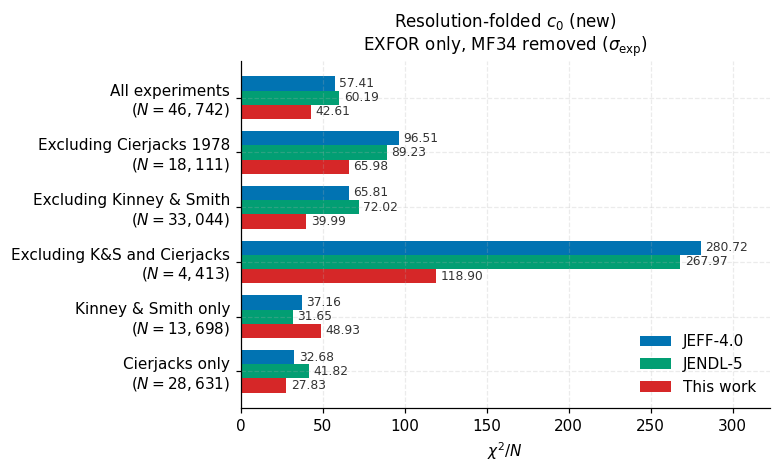

In [9]:
plot_subset_panel('folded_c0')

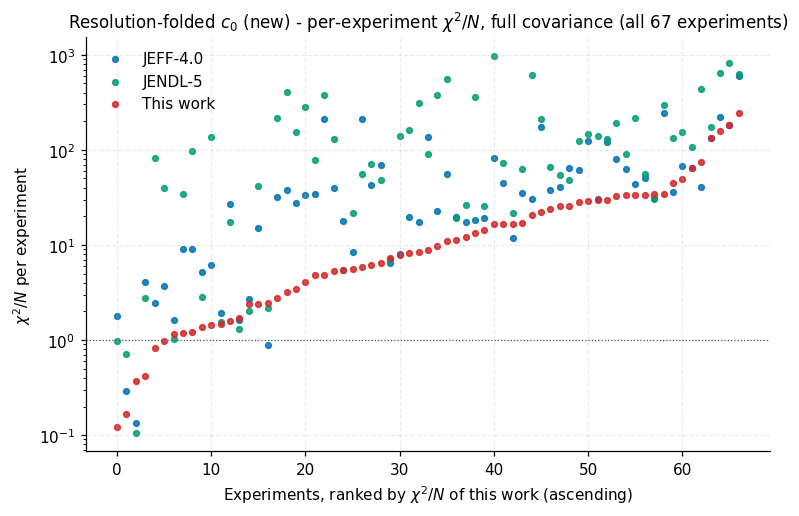

In [10]:
plot_strip('folded_c0')

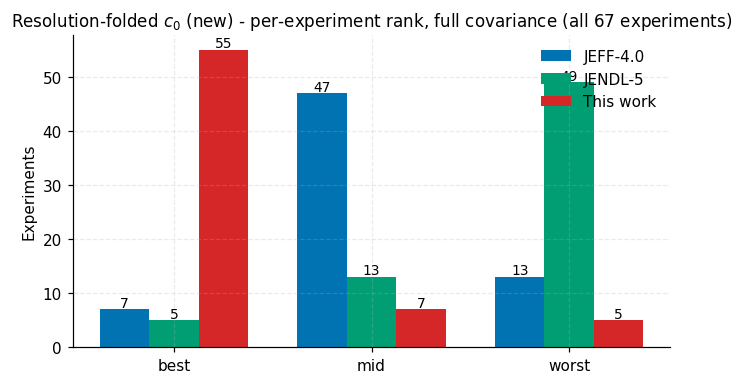

In [11]:
plot_wintally('folded_c0')

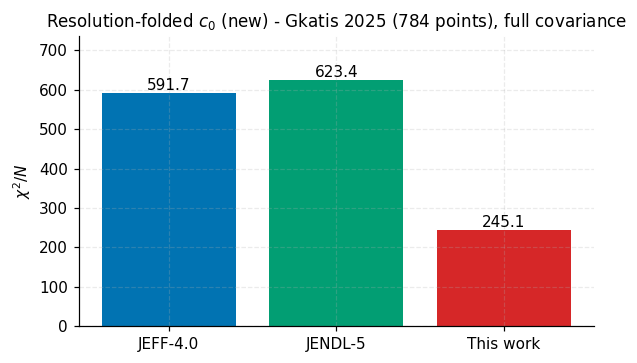

In [12]:
plot_gkatis('folded_c0')

## Both-folded $c_0$ and $a_l$ — resolution-window sweep (run_080)

Extends the resolution fold to the angular **shape**: each library's $a_l$ is
averaged over the experiment's TOF window (truncated Gaussian) alongside $c_0$, at
half-widths of $\pm1\sigma$ and $\pm3\sigma$. Comparing against `folded_c0` (which
folds $c_0$ only) isolates how much broadening the shape matters; comparing
$\pm1\sigma$ against $\pm3\sigma$ shows the window-width sensitivity. `c_0` is
identical to `folded_c0`'s only in the wide-window limit, so differences here come
from both the narrower window and the folded shape.

Run the cluster jobs for `folded_al_c0_ns1` / `folded_al_c0_ns3` first (precompute
`scripts/precompute_chi2_folded_al_c0.py` at `N_SIGMA=1.0` then `3.0`, then
`chi2_analysis_cluster.py`). Until the reports exist, the loaders above print
`[skip]` and the cells in this section produce nothing.

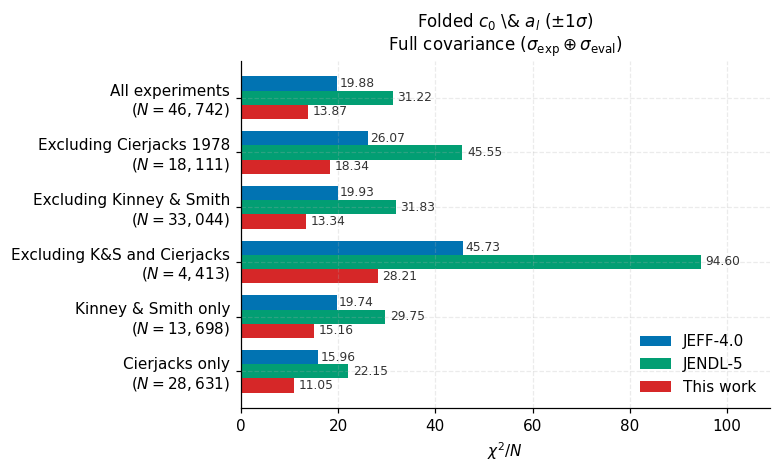

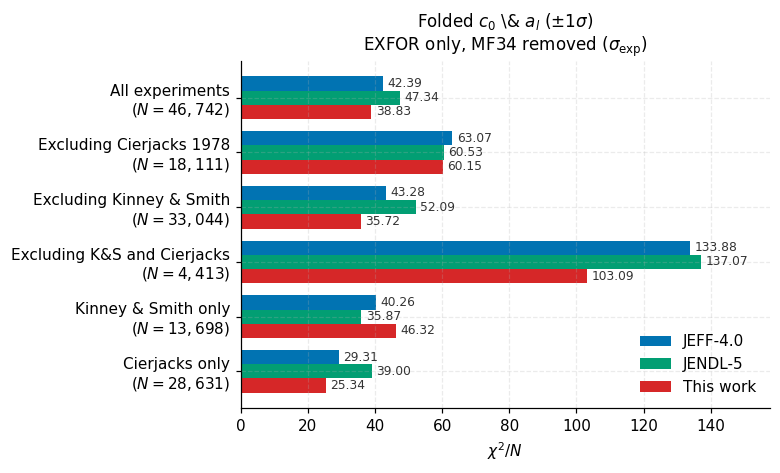

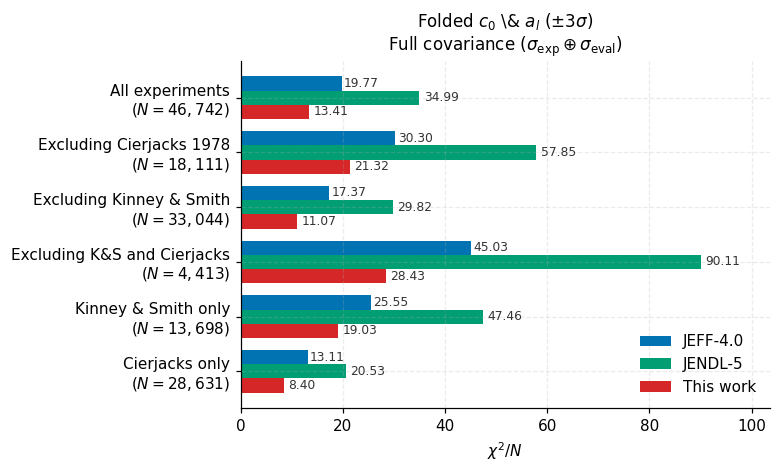

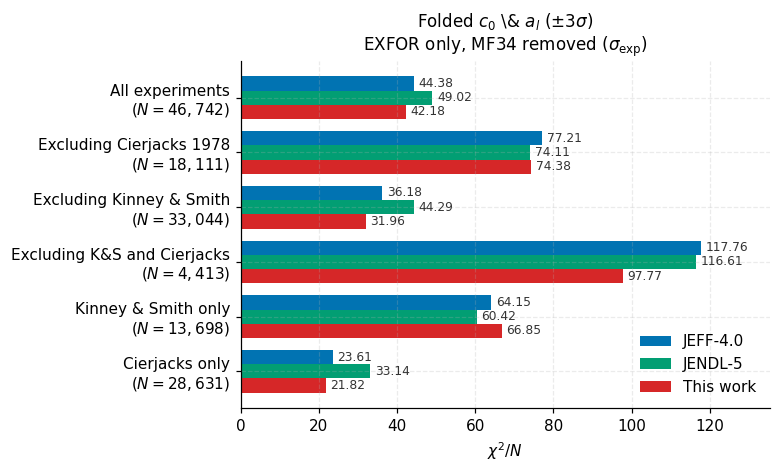

In [13]:
# Subset panels - both covariance budgets, both window widths.
for m in ('folded_al_c0_ns1', 'folded_al_c0_ns3'):
    if m in SUMM:
        plot_subset_panel(m)

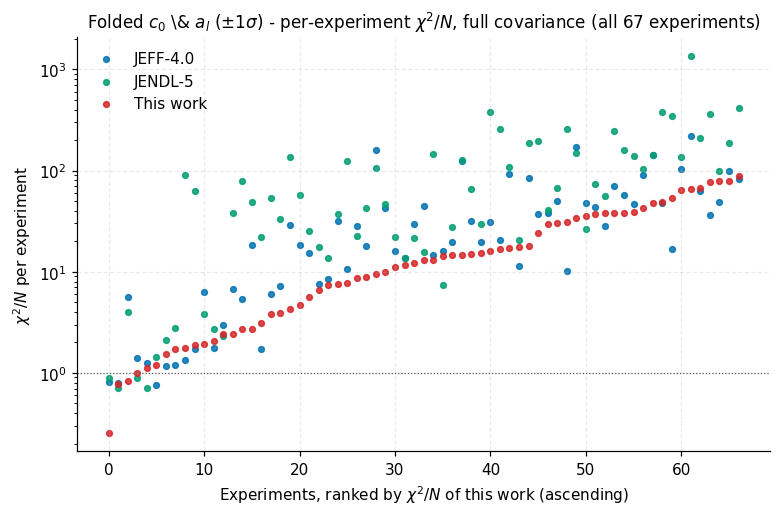

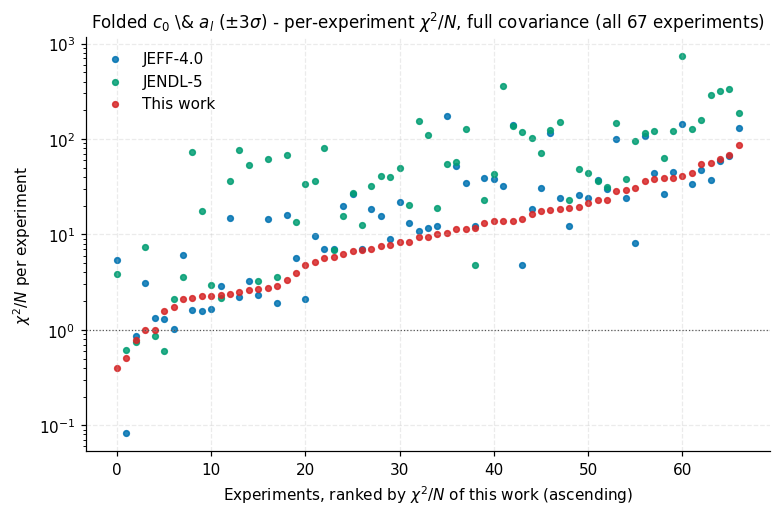

In [14]:
# Per-experiment strip, both window widths.
for m in ('folded_al_c0_ns1', 'folded_al_c0_ns3'):
    if m in PER_EXP:
        plot_strip(m)

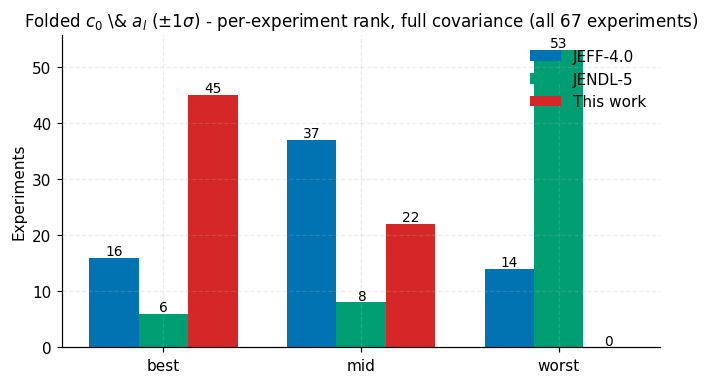

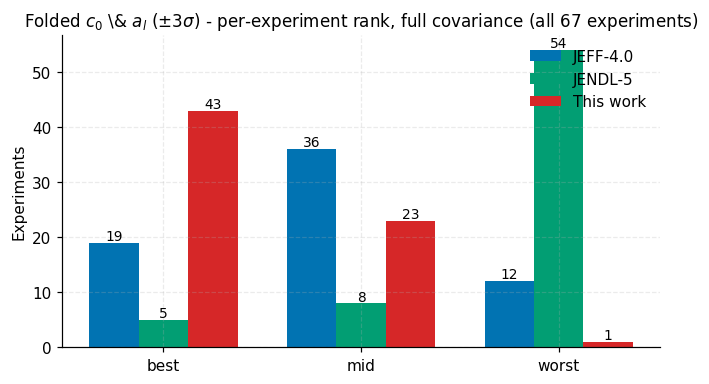

In [15]:
# Per-experiment win-tally, both window widths.
for m in ('folded_al_c0_ns1', 'folded_al_c0_ns3'):
    if m in SUMM:
        plot_wintally(m)

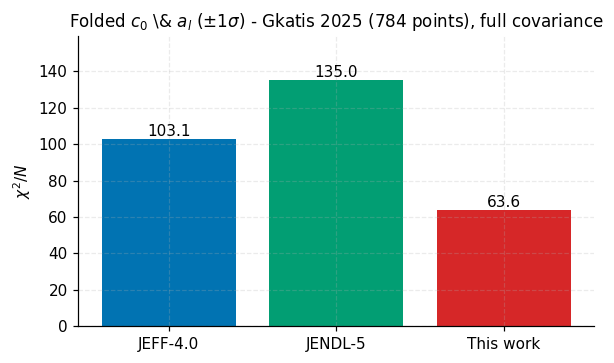

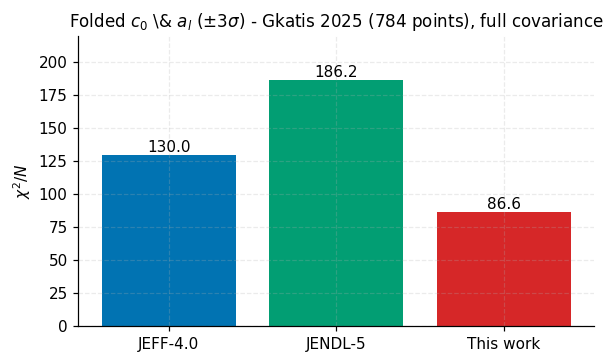

In [16]:
# Gkatis 2025 out-of-sample case study, both window widths.
for m in ('folded_al_c0_ns1', 'folded_al_c0_ns3'):
    if m in PER_EXP:
        plot_gkatis(m)

In [17]:
# Effect of folding the shape a_l and of the window width: folded_c0 (c0 only)
# vs folded_al_c0 at +/-1 sigma and +/-3 sigma, full-covariance (V4) chi2/N.
def fold_sweep_table(sub):
    methods = [m for m in ('folded_c0', 'folded_al_c0_ns1', 'folded_al_c0_ns3')
               if m in SUMM]
    if not methods:
        print('No folded results loaded yet.')
        return
    print(f'\nSubset: {sub}  (N = {subset_N(methods[0], sub):,} points), '
          f'budget = full covariance (V4)')
    print(f'  {"methodology":<18s} ' + ''.join(f'{l:>12s}' for l in LIBS))
    for m in methods:
        row = ''.join(f'{subset_total(m, sub, l, "V4"):12.2f}' for l in LIBS)
        print(f'  {m:<18s} {row}')

for sub in ('all', 'no_Cierjacks', 'only_KS'):
    fold_sweep_table(sub)


Subset: all  (N = 46,742 points), budget = full covariance (V4)
  methodology            JEFF-4.0     JENDL-5   This work
  folded_c0                 35.55       45.71       25.10
  folded_al_c0_ns1          19.88       31.22       13.87
  folded_al_c0_ns3          19.77       34.99       13.41

Subset: no_Cierjacks  (N = 18,111 points), budget = full covariance (V4)
  methodology            JEFF-4.0     JENDL-5   This work
  folded_c0                 61.15       76.95       42.02
  folded_al_c0_ns1          26.07       45.55       18.34
  folded_al_c0_ns3          30.30       57.85       21.32

Subset: only_KS  (N = 13,698 points), budget = full covariance (V4)
  methodology            JEFF-4.0     JENDL-5   This work
  folded_c0                 31.48       30.97       33.77
  folded_al_c0_ns1          19.74       29.75       15.16
  folded_al_c0_ns3          25.55       47.46       19.03


## Cross-methodology headline + manuscript delta

`headline_table` prints $\chi^2/N$ for all three $c_0$ methodologies side by side
(diagonal `V1` and full-covariance `V4`); the last cell prints the exact run_079
to run_080 changes for the numbers currently quoted in the chapter prose.

In [18]:
# Headline chi2/N across every c0 methodology loaded, run_080.
def headline_table(sub):
    print(f'\nSubset: {sub}  (N = {subset_N("exfor_c0", sub):,} points)')
    print(f'  {"methodology":<18s} {"budget":<16s} ' + ''.join(f'{l:>12s}' for l in LIBS))
    for m in ('exfor_c0', 'folded_c0', 'library_c0',
              'folded_al_c0_ns1', 'folded_al_c0_ns3'):
        if m not in SUMM:
            continue
        for v in ('V1', 'V4'):
            row = ''.join(f'{subset_total(m, sub, l, v):12.2f}' for l in LIBS)
            print(f'  {m:<18s} {BUDGET_NAME[v]:<16s} {row}')

for sub in ('all', 'no_Cierjacks'):
    headline_table(sub)


Subset: all  (N = 46,742 points)
  methodology        budget               JEFF-4.0     JENDL-5   This work
  exfor_c0           diagonal                12.93        6.50        4.74
  exfor_c0           full covariance         20.01       24.50        8.02
  folded_c0          diagonal                 8.37        7.68        7.82
  folded_c0          full covariance         35.55       45.71       25.10
  library_c0         diagonal                13.89        8.72       13.98
  library_c0         full covariance         17.25       18.60       12.42
  folded_al_c0_ns1   diagonal                 7.36        6.74        6.84
  folded_al_c0_ns1   full covariance         19.88       31.22       13.87
  folded_al_c0_ns3   diagonal                 6.24        6.07        6.12
  folded_al_c0_ns3   full covariance         19.77       34.99       13.41

Subset: no_Cierjacks  (N = 18,111 points)
  methodology        budget               JEFF-4.0     JENDL-5   This work
  exfor_c0           di

In [19]:
# --- Manuscript delta: what to update in the Chapter-3 prose/tables ---
# The text currently quotes the run_079 EXFOR-c0 full-covariance (V4) numbers.
# run_080 (rebuilt pipeline: merge_mf34 + MF34_to_MG cache fix) shifts them
# slightly; the ordering and the "This work is best" story are unchanged.
def show_delta(name, old, new):
    print(f'  {name:<12s} {old:8.2f}  ->  {new:8.2f}   (delta {new - old:+.2f})')

print('EXFOR c0, full covariance (V4), all 67 experiments  [prose: 8.5 / 20.5 / 25.4]:')
for lib, old in (('This work', 8.5), ('JEFF-4.0', 20.5), ('JENDL-5', 25.4)):
    show_delta(lib, old, subset_total('exfor_c0', 'all', lib, 'V4'))

print('\nGkatis 2025 (784 pts), EXFOR c0, full covariance (V4)  [prose: 42.4 / 591.7 / 457.9]:')
g = PER_EXP['exfor_c0']['all']
grow = g[g['experiment_id'].astype(str) == '27673002'].iloc[0]
for lib_raw, lib_disp, old in (('This_work', 'This work', 42.4),
                               ('JEFF', 'JEFF-4.0', 591.7),
                               ('JENDL', 'JENDL-5', 457.9)):
    show_delta(lib_disp, old, float(grow[col(lib_raw, 'V4')]))

EXFOR c0, full covariance (V4), all 67 experiments  [prose: 8.5 / 20.5 / 25.4]:
  This work        8.50  ->      8.02   (delta -0.48)
  JEFF-4.0        20.50  ->     20.01   (delta -0.49)
  JENDL-5         25.40  ->     24.50   (delta -0.90)

Gkatis 2025 (784 pts), EXFOR c0, full covariance (V4)  [prose: 42.4 / 591.7 / 457.9]:
  This work       42.40  ->     41.29   (delta -1.11)
  JEFF-4.0       591.70  ->    568.49   (delta -23.21)
  JENDL-5        457.90  ->    452.52   (delta -5.38)
